In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
# local mods
import geo_utils as geo
import clean_utils as clean
from sklearn.cluster import KMeans

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
import numpy as np

In [8]:
# Path to the folder containing spreadsheet files
#path = "spreadsheets/*.csv"
#path = "test1/*.xlsx"
#path = "test3/*.xlsx"
path = "test4/*.xlsx"

In [9]:
files = glob.glob(path)

# Load each file into a list of DataFrames
df_list = [pd.read_excel(file) for file in files]

# Combine them into one master DataFrame and drop na
master_df = pd.concat(df_list, ignore_index=True)
master_df = master_df.dropna(subset=["intersection","text_on_sign_exact"])

In [10]:
# clean the strings so they have punctuation removed and such
master_df = clean.clean_string_columns(master_df,columns=["text_on_sign_exact"])

In [40]:
# import additional data
coordinates = pd.read_csv("coordinate_dict5.csv")
platte_river_points = pd.read_csv("platte_points.csv")

In [41]:
coordinates.to_csv

<bound method NDFrame.to_csv of              intersection     intersection_text                          cd  \
0         arapahoe-havana       arapahoe-havana  39°35'42.5"N 104°52'00.4"W   
1         arapahoe-peoria       arapahoe-peoria  39°35'42.3"N 104°50'53.4"W   
2           arapahoe-lima         arapahoe-lima  39°35'42.1"N 104°51'26.9"W   
3         arapahoe-jordan       arapahoe-jordan  39°35'41.9"N 104°49'15.8"W   
4           easter-havana         easter-havana  39°35'16.1"N 104°52'00.5"W   
..                    ...                   ...                         ...   
159          lowry-quebec          lowry-quebec  39°43'01.5"N 104°54'13.3"W   
160         florida-wolff         florida-wolff  39°41'22.3"N 105°02'52.8"W   
161  mississippi-tennyson  mississippi-tennyson  39°41'48.4"N 105°02'37.3"W   
162         lehigh-parker         lehigh-parker  39°38'50.3"N 104°49'44.0"W   
163           pine-20mile           pine-20mile  39°32'38.8"N 104°46'31.8"W   

     latitude  long

In [42]:
# drop na and transition latitude and longitude strings
# to a float format
coordinates[["latitude", "longitude"]] = (
    coordinates["cd"]
    .dropna()
    .apply(geo.parse_dms_coordinate)
    .apply(pd.Series)
)

In [43]:
# merge the coordinate sheet with the master sheet
# so the data can be trained
training_data_raw = master_df.merge(
    coordinates[["intersection", "latitude", "longitude", "zip", "city"]],
    on="intersection",
    how="left"
)

In [44]:
training_data_raw

,intersection,text_on_sign_exact,code_type,notes,,latitude,longitude,zip,city
0,mississippi-peoria,walgreens,storefront_main,NaN,NaN,39.696639,-104.847139,80010.0,aurora
1,mississippi-peoria,right lane must turn right,street_sign,NaN,NaN,39.696639,-104.847139,80010.0,aurora
2,mississippi-peoria,shotokan karate dojo,storefront_main,NaN,NaN,39.696639,-104.847139,80010.0,aurora
3,mississippi-peoria,american shotokan karate federation colorado,storefront_accessory,NaN,NaN,39.696639,-104.847139,80010.0,aurora
4,mississippi-peoria,open,storefront_accessory,NaN,NaN,39.696639,-104.847139,80010.0,aurora
...,...,...,...,...,...,...,...,...,...
2553,colfax-pennsylvannia,loading only,street_sign,NaN,NaN,39.740028,-104.981083,80203.0,denver
2554,colfax-logan,tasty thai,NaN,NaN,NaN,39.740028,-104.982361,80203.0,denver
2555,colfax-logan,cathedral basilica,NaN,NaN,NaN,39.740028,-104.982361,80203.0,denver
2556,colfax-logan,fork and spoon,NaN,NaN,NaN,39.740028,-104.982361,80203.0,denver


In [45]:
# create a dataframe that has one row per instersection with
# all of the text combined for that intersection
intersection_df = (
    training_data_raw
    .groupby("intersection")
    .agg({
        "text_on_sign_exact": " ".join,
        "latitude": "first",
        "longitude": "first",
        "zip": "first",
        "city": "first"
    })
    .reset_index()
    .rename(columns={"text_on_sign_exact": "text_blob"})
)

In [46]:
intersection_df = intersection_df.dropna(subset=["latitude","longitude"])

In [47]:
intersection_df.to_csv("cleaned_concatenated.csv")

In [48]:
coords = intersection_df[["latitude", "longitude"]]

kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")

intersection_df["spatial_cluster"] = kmeans.fit_predict(coords)

In [49]:
intersection_df

,intersection,text_blob,latitude,longitude,zip,city,spatial_cluster
1,11th-santafe,armstrong dance center 711 gas is 329 brick bu...,39.733667,-104.998694,80204.0,denver,2
2,11th-syracuse,11th ave syracuse st no turn on red uhaul syra...,39.732917,-104.898806,80220.0,denver,1
3,11th-yosemite,11th ave yosemite st 7 eleven slurpee taw win ...,39.732861,-104.884750,80010.0,aurora,1
4,14th-lincoln,ralph l carr colorado judicial center fransen ...,39.738472,-104.986139,80203.0,denver,2
5,15th-larimer,ariat stetson sidewalk closed ahead pedestrian...,39.748306,-104.998611,80202.0,denver,2
...,...,...,...,...,...,...,...
96,quebec-iliff,e evans ave s quebec st e iliff ave right lane...,39.676611,-104.903583,80224.0,denver,1
97,quincy-broadway,dip yamaha home theater parasound open marantz...,39.638583,-104.987806,80113.0,englewood,0
98,tennessee-federal,novacane tony pho miracle touch kim son jewele...,39.698611,-105.025083,NaN,sheridan,2
99,tufts-broadway,lucky u motel 4575 office ace hardware welcome...,39.633139,-104.987861,80113.0,englewood,0


In [50]:
#intersection_df = intersection_df[
#    intersection_df["city"].isin(["denver", "englewood", "cherry creek", "aurora"])
#]

In [51]:
intersection_df

,intersection,text_blob,latitude,longitude,zip,city,spatial_cluster
1,11th-santafe,armstrong dance center 711 gas is 329 brick bu...,39.733667,-104.998694,80204.0,denver,2
2,11th-syracuse,11th ave syracuse st no turn on red uhaul syra...,39.732917,-104.898806,80220.0,denver,1
3,11th-yosemite,11th ave yosemite st 7 eleven slurpee taw win ...,39.732861,-104.884750,80010.0,aurora,1
4,14th-lincoln,ralph l carr colorado judicial center fransen ...,39.738472,-104.986139,80203.0,denver,2
5,15th-larimer,ariat stetson sidewalk closed ahead pedestrian...,39.748306,-104.998611,80202.0,denver,2
...,...,...,...,...,...,...,...
96,quebec-iliff,e evans ave s quebec st e iliff ave right lane...,39.676611,-104.903583,80224.0,denver,1
97,quincy-broadway,dip yamaha home theater parasound open marantz...,39.638583,-104.987806,80113.0,englewood,0
98,tennessee-federal,novacane tony pho miracle touch kim son jewele...,39.698611,-105.025083,NaN,sheridan,2
99,tufts-broadway,lucky u motel 4575 office ace hardware welcome...,39.633139,-104.987861,80113.0,englewood,0


# Predicting a Single Coordinate Based on Language Data from an Intersection
## Distance

In [52]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate great-circle distance between two points on Earth.
    
    Returns distance in kilometers.
    """

    R = 6371  # Earth radius in km

    # convert degrees to radians
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)

    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    # differences
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # haversine formula
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [53]:
# assign variables
X = intersection_df["text_blob"]

# for using geographical coordinates
y = intersection_df[["latitude", "longitude"]]

# for using kmean clusters
# y = intersection_df["spatial_cluster"]   # or "city", "region_label", etc.

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state= 46#24#2 # 55 #46 # 42
)

In [100]:
coord_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char",
        ngram_range=(2, 5),
        lowercase=True,
        min_df=2
    )),
    ("regressor", MultiOutputRegressor(
        Ridge(alpha=0.1)
    ))
])

In [101]:
X_test

34    bicycles dog grooming martial arts giant centi...
92    kneaders bakery cafe bok finacail braucher cha...
14    bus only 1800 18th st one way 18th st glenarm ...
24    the pza pizzeria pizza closed colorado histori...
77    monaco st pkwy leetsdale dr turning vehicles g...
17    1600 e franklin st 22nd ave stop stop stop sto...
96    e evans ave s quebec st e iliff ave right lane...
76    leetsdale dr holly st midwestone bank 24 hour ...
42    olive garden trader joes one way street sign d...
15    1700 illegible exit only do not enter 19th str...
38    mcdonalds tamale kitchen canton chinese restau...
50    time offline bargain house tasty thai theride ...
52    tobins liquor liquor tobins liquor jose cuervo...
73    malloys bar and grill starbucks meadows plaza ...
48    tycoon ramen sushi happy hr menus fork and spo...
39    city buffet peak kia peak honda world boot bar...
19    the shade store california closets design stud...
57    car wash car wash mc donalds big bills ny 

In [102]:
# fit the model
# model.fit(X_train, y_train)
coord_model.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [103]:
pred_coords = coord_model.predict(X_test)

pred_df = y_test.copy()
pred_df["pred_latitude"] = pred_coords[:, 0]
pred_df["pred_longitude"] = pred_coords[:, 1]

pred_df.head()

,latitude,longitude,pred_latitude,pred_longitude
34,39.595083,-104.848167,39.623434,-104.929926
92,39.518861,-104.765083,39.594303,-104.905106
14,39.745750,-104.988083,39.755999,-104.988817
24,39.725778,-104.998583,39.691243,-104.984070
77,39.702917,-104.912861,39.689391,-104.945574


In [104]:
# assigning mins and maxs to set bounds for random points
lat_min = min(pred_df["latitude"].min(), pred_df["pred_latitude"].min())
lat_max = max(pred_df["latitude"].max(), pred_df["pred_latitude"].min())
long_min = min(pred_df["longitude"].min(),pred_df["pred_longitude"].min())
long_max = max(pred_df["longitude"].max(), pred_df["longitude"].max())

In [118]:
# create random points for latitude and longitude
np.random.seed(47)

pred_df["random_latitude"] = np.random.uniform(
    lat_min,
    lat_max,
    size=len(pred_df)
)

pred_df["random_longitude"] = np.random.uniform(
    long_min,
    long_max,
    size=len(pred_df)
)

In [119]:
# append random error to spreadsheet
pred_df["random_error_km"] = haversine_distance(
    pred_df["latitude"],
    pred_df["longitude"],
    pred_df["random_latitude"],
    pred_df["random_longitude"]
)

In [120]:
mae_lat = mean_absolute_error(y_test["latitude"], pred_df["pred_latitude"])
mae_lng = mean_absolute_error(y_test["longitude"], pred_df["pred_longitude"])

print("Latitude MAE:", mae_lat)
print("Longitude MAE:", mae_lng)

Latitude MAE: 0.038133641050926315
Longitude MAE: 0.05853023728621646


In [121]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [122]:
pred_df["error_km"] = haversine_distance(
    pred_df["latitude"],
    pred_df["longitude"],
    pred_df["pred_latitude"],
    pred_df["pred_longitude"]
)

pred_df[[
    "latitude",
    "longitude",
    "pred_latitude",
    "pred_longitude",
    "error_km"
]].head()

,latitude,longitude,pred_latitude,pred_longitude,error_km
34,39.595083,-104.848167,39.623434,-104.929926,7.680711
92,39.518861,-104.765083,39.594303,-104.905106,14.644921
14,39.745750,-104.988083,39.755999,-104.988817,1.141307
24,39.725778,-104.998583,39.691243,-104.984070,4.035830
77,39.702917,-104.912861,39.689391,-104.945574,3.177325


In [123]:
print("Mean error in km:", pred_df["error_km"].mean())
print("Median error in km:", pred_df["error_km"].median())

Mean error in km: 7.3589508558512415
Median error in km: 7.712497726571569


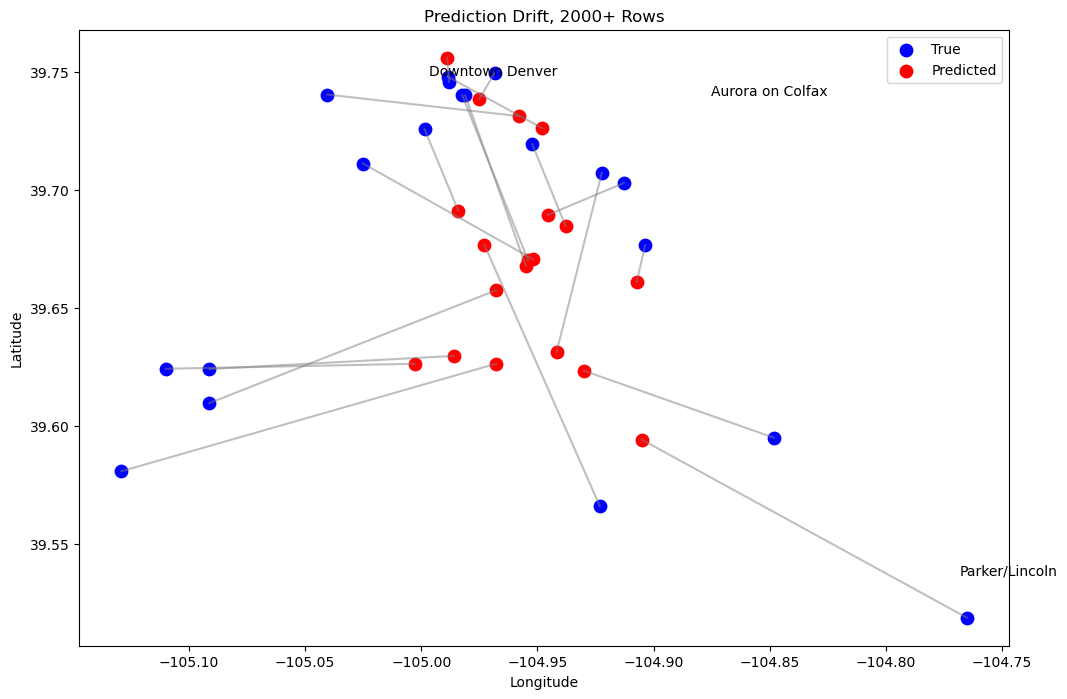

In [124]:
plt.figure(figsize=(12,8))

plt.text(-104.996583333333, 39.74852777777778,"Downtown Denver")
plt.text(-104.875277777777, 39.74022222222222, "Aurora on Colfax")
plt.text(-104.768055555555, 39.53711111111111, "Parker/Lincoln")


# true locations
plt.scatter(
    pred_df["longitude"],
    pred_df["latitude"],
    color="blue",
    label="True",
    s=80
)

# predicted locations
plt.scatter(
    pred_df["pred_longitude"],
    pred_df["pred_latitude"],
    color="red",
    label="Predicted",
    s=80
)

# arrows / lines
for _, row in pred_df.iterrows():

    plt.plot(
        [row["longitude"], row["pred_longitude"]],
        [row["latitude"], row["pred_latitude"]],
        color="gray",
        alpha=0.5
    )



plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title("Prediction Drift, 2000+ Rows")

plt.legend()

plt.savefig("prediction_drift2000_rows.png")

plt.show()

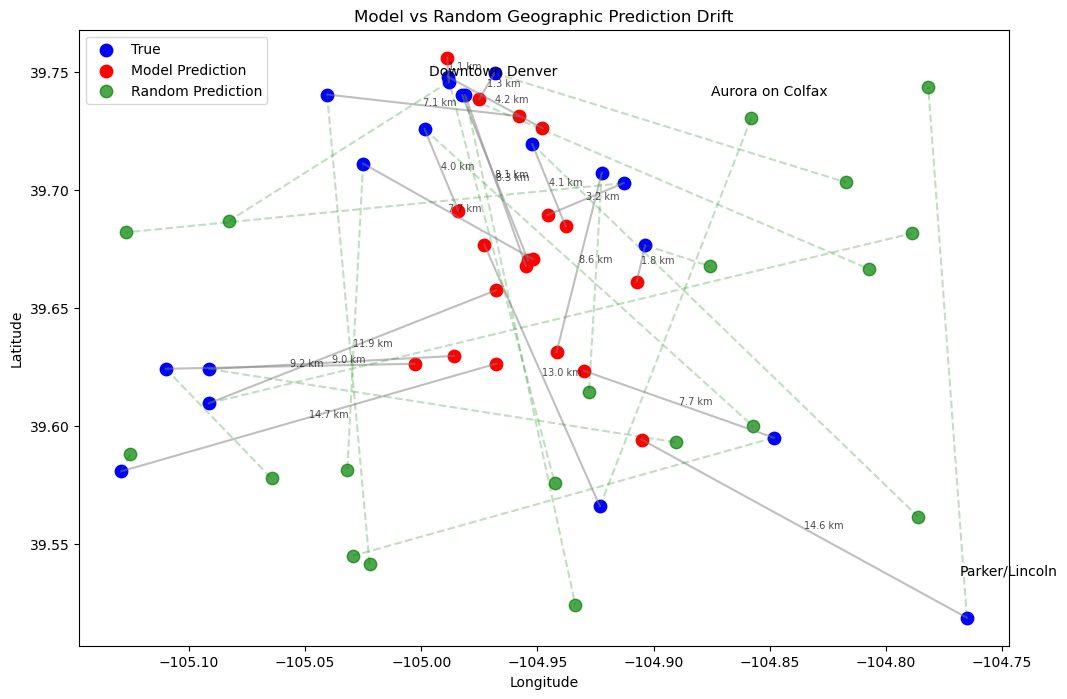

In [125]:
plt.figure(figsize=(12,8))

plt.text(
    -104.996583333333,
    39.74852777777778,
    "Downtown Denver"
)

plt.text(
    -104.875277777777,
    39.74022222222222,
    "Aurora on Colfax"
)
plt.text(
    -104.768055555555,
    39.53711111111111, 
    "Parker/Lincoln")

# TRUE LOCATIONS
plt.scatter(
    pred_df["longitude"],
    pred_df["latitude"],
    color="blue",
    label="True",
    s=80
)

# MODEL PREDICTIONS
plt.scatter(
    pred_df["pred_longitude"],
    pred_df["pred_latitude"],
    color="red",
    label="Model Prediction",
    s=80
)

# RANDOM PREDICTIONS
plt.scatter(
    pred_df["random_longitude"],
    pred_df["random_latitude"],
    color="green",
    label="Random Prediction",
    s=80,
    alpha=0.7
)

# MODEL LINES + ERROR LABELS
for _, row in pred_df.iterrows():

    # model prediction line
    plt.plot(
        [row["longitude"], row["pred_longitude"]],
        [row["latitude"], row["pred_latitude"]],
        color="gray",
        alpha=0.5
    )

    # midpoint for annotation
    mid_x = (
        row["longitude"] +
        row["pred_longitude"]
    ) / 2

    mid_y = (
        row["latitude"] +
        row["pred_latitude"]
    ) / 2

    # model error label
    plt.text(
        mid_x,
        mid_y,
        f"{row['error_km']:.1f} km",
        fontsize=7,
        alpha=0.7,
        color="black"
    )

# RANDOM LINES
for _, row in pred_df.iterrows():

    plt.plot(
        [row["longitude"], row["random_longitude"]],
        [row["latitude"], row["random_latitude"]],
        color="green",
        alpha=0.25,
        linestyle="dashed"
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title("Model vs Random Geographic Prediction Drift")

plt.legend()

plt.savefig("test_random_vs_model.png", dpi=300)

plt.show()

In [126]:
print("MODEL")
print(pred_df["error_km"].describe())

print("\nRANDOM")
print(pred_df["random_error_km"].describe())

MODEL
count    19.000000
mean      7.358951
std       4.248707
min       1.141307
25%       4.048440
50%       7.712498
75%       9.107510
max      14.726861
Name: error_km, dtype: float64

RANDOM
count    19.000000
mean     16.159183
std       7.316825
min       0.871141
25%      12.166073
50%      17.562218
75%      20.857007
max      27.127175
Name: random_error_km, dtype: float64


# Predict Possible Areas Based on Intersection Text Data
# using "Neighbors

In [127]:
# grab the vectorizer to visualize
# vectorizer = model.named_steps["tfidf"]
vectorizer = coord_model.named_steps["tfidf"]

X_all_tfidf = vectorizer.transform(intersection_df["text_blob"])

In [128]:
from sklearn.neighbors import NearestNeighbors

nn_model = NearestNeighbors(
    n_neighbors=5,
    metric="cosine"
)

nn_model.fit(X_all_tfidf)

,n_neighbors,5
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [129]:
def find_linguistic_neighbors(text, intersection_df, vectorizer, nn_model, n_neighbors=5):
    text_vec = vectorizer.transform([text])

    distances, indices = nn_model.kneighbors(
        text_vec,
        n_neighbors=n_neighbors
    )

    results = intersection_df.iloc[indices[0]].copy()
    results["cosine_distance"] = distances[0]
    results["similarity"] = 1 - results["cosine_distance"]

    return results[
        [
            "intersection",
            "city",
            "latitude",
            "longitude",
            "similarity",
            "text_blob"
        ]
    ]

In [130]:
def plot_knn_triangulation(knn_df, n, actual:tuple):
    knn_df = knn_df[:n]
    average = triangulate_mean(knn_df, n)
    plt.scatter(knn_df["longitude"], knn_df["latitude"],
           label = f"Top {n} Projected Points")
    plt.scatter(actual[0], actual[1], label = "Actual Intersection")
    plt.scatter(average[0], average[1], label = "Triangulation")
    plt.legend()
    plt.show()

In [131]:
def triangulate_mean(knn_df, n):
    knn_df = knn_df[:n]
    knn_longitude_average = knn_df["longitude"].mean()
    knn_latitude_average = knn_df["latitude"].mean()
    return((knn_longitude_average, knn_latitude_average))

In [138]:
# test a query on Grant
query_text = """
taco river autozone pho vietnamnese restaurant crawfish market raw
"""
query_point = (-105.025207, 39.694929) 

test_knn = find_linguistic_neighbors(
    query_text,
    intersection_df,
    vectorizer,
    nn_model,
    n_neighbors=5
)

In [139]:
test_knn

,intersection,city,latitude,longitude,similarity,text_blob
47,colfax-ivanhoe,denver,39.740139,-104.921694,0.190578,yolo rum you only leave once original myxed up...
73,kencaryl-simms,littleton,39.580889,-105.129083,0.184056,malloys bar and grill starbucks meadows plaza ...
50,colfax-pennsylvannia,denver,39.740028,-104.981083,0.183126,time offline bargain house tasty thai theride ...
37,arkansas-federal,sheridan,39.691028,-105.025083,0.175813,pho 95 vectra bank family dollar gen x vietnam...
86,mississippi-peoria,aurora,39.696639,-104.847139,0.170322,walgreens right lane must turn right shotokan ...


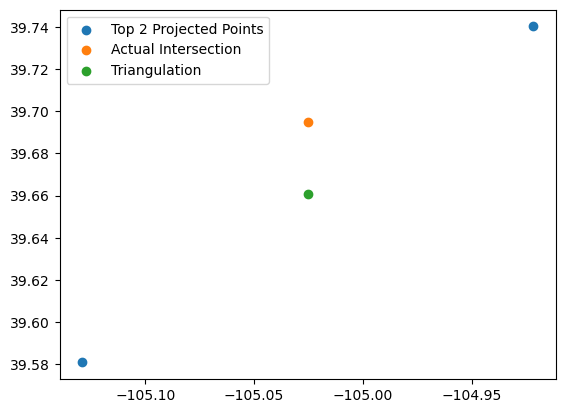

In [140]:
plot_knn_triangulation(test_knn, n= 2, actual = query_point)

In [43]:
# take the top four closest in linguistic space
test_knn = test_knn[:3]

knn_longitude_average = test_knn["longitude"].mean()
knn_latitude_average = test_knn["latitude"].mean()

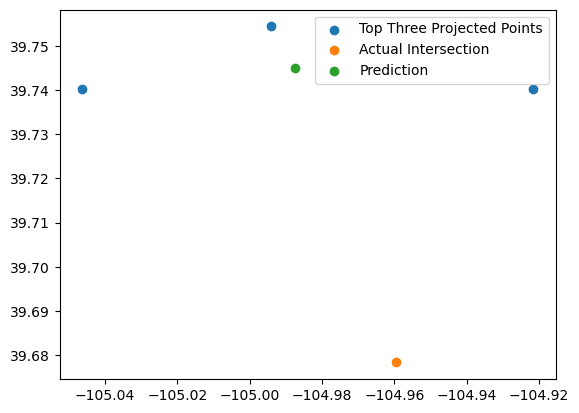

In [44]:
plt.scatter(test_knn["longitude"], test_knn["latitude"],
           label = "Top Three Projected Points")
plt.scatter(query_point[0], query_point[1], label = "Actual Intersection")
plt.scatter(knn_longitude_average, knn_latitude_average, label = "Prediction")
plt.legend()
plt.show()

In [ ]:
# visualize the gram weights
X_test_tfidf = vectorizer.transform(X_test)
feature_names = vectorizer.get_feature_names_out()

# model for kmean space
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char",
        ngram_range=(3, 5),
        lowercase=True,
        min_df=2
    )),
    ("clf", LogisticRegression(
        max_iter=5000
    ))
])

# for kmean clusters
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
feature_names

In [ ]:
# test looking at one row
row = X_test_tfidf[1]
weights = row.toarray()[0]

In [ ]:
tfidf_scores = list(zip(feature_names, weights))

In [ ]:
X_test

In [ ]:
preds = model.predict(X_test)

print(classification_report(y_test, preds))
print(confusion_matrix(y_test, preds))
print(type(preds))

In [ ]:
plt.figure(figsize=(10, 8))

plt.scatter(
    intersection_df["longitude"],   # x-axis
    intersection_df["latitude"],    # y-axis
    c=intersection_df["spatial_cluster"]
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Clusters by Intersection")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.scatter(coordinates["longitude"], coordinates["latitude"], color="orange")
ax.plot(platte_river_points["platte_long"], platte_river_points["platte_lat"])
ax.set_xlabel("Longitude", weight = "semibold")
ax.set_ylabel("Latitude", weight="semibold")
ax.set_title("Intersections in the Greater Denver Metro Area", weight="bold")
fig.show()